# A Data-Adapted Event-Driven Clustering Algorithm for Photon Signature Detection and Discrimination
## Hila Monsonego (ID 213069412)

## Imports

In [1]:
import numpy as np
import pandas as pd
import pickle as pkl
import matplotlib.pyplot as plt
import requests
from io import BytesIO
from matplotlib import cm

## Load the data

In [2]:
data=pkl.load(BytesIO(requests.get('https://github.com/hilamonso/Timepix3-data/raw/refs/heads/main/data_example_pkl.pickle').content))

## A clustering algorithm for asynchronous event-driven data

In [3]:
def neighborhood(pixel,N):
    (x,y)=pixel
    neighbors=[(s,v) for s in range(x-N,x+N+1) for v in range(y-N,y+N+1)]
    return neighbors


def algorithm(data,alpha,beta,N,during):
    data=data[data['toa']<data['toa'][0]+during]
    t=data['toa']
    x=np.array(data['x'],dtype=np.int64)
    y=np.array(data['y'],dtype=np.int64)
    
    clusters=[]
    clusters_centers=[]
    f=np.zeros((256,256))
    time_surface=np.zeros((256,256))
    history=[[[] for _ in range(256)] for _ in range(256)]
    
    for i in range(len(t)):
        current_time=t[i]
        current_pixel=(x[i],y[i])
        the_neighborhood=neighborhood(current_pixel,N)
        flag=0
        for pixel in the_neighborhood:
            if pixel[0]<256 and pixel[1]<256 and pixel[0]>0 and pixel[1]>0:
                f[pixel]=beta+f[pixel]*np.exp(-alpha*(current_time-time_surface[pixel]))
                time_surface[pixel]=current_time
                history[pixel[0]][pixel[1]].append((t[i],x[i],y[i]))
                if f[pixel]>=1:
                    clusters_centers.append([t[i],x[i],y[i]])
                    clusters.append(history[pixel[0]][pixel[1]])
                    history[pixel[0]][pixel[1]]=[]
                    flag=1
                    break
        if flag==1:
            for pixel in the_neighborhood:
                if pixel[0]<256 and pixel[1]<256 and pixel[0]>0 and pixel[1]>0:
                    f[pixel]=0
                    time_surface[pixel]=current_time
                    history[pixel[0]][pixel[1]]=[]

    clusters_centers=np.array(clusters_centers)
    
    M=np.zeros((256,256))
    for i in range(t.shape[0]):
        M[x[i],y[i]]+=1
    
    fig = plt.figure(1)
    ax = fig.add_subplot(1, 1, 1)
    ax.imshow(np.log(M.T+1),cmap='gray')
    if len(clusters_centers)>0:
        plt.plot(clusters_centers[:,1],clusters_centers[:,2],'g.')
    plt.show()
    return clusters, clusters_centers

###  alpha, beta, N, during=1e-10, 0.3, 1, 0.01

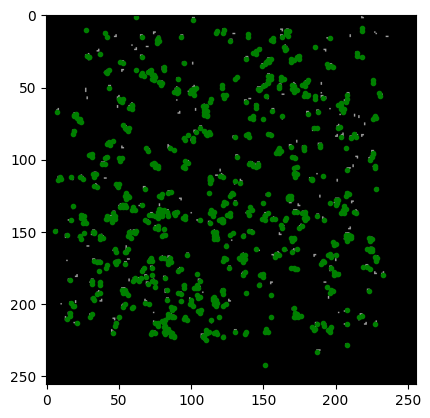

In [4]:
alpha, beta, N, during=1e-10, 0.3, 1, 0.01
clusters, clusters_centers=algorithm(data, alpha, beta, N, during)

### Histogram of the first 0.01s

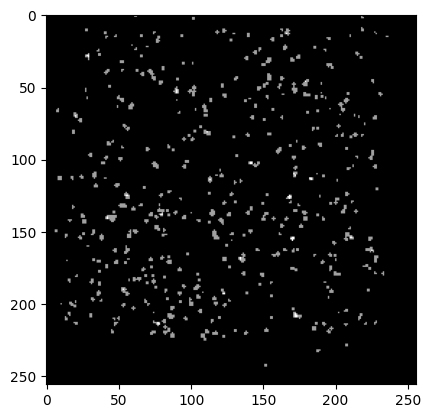

In [5]:
alpha, beta, N, during=1e-10, 0.3, 0, 0.01
clusters, clusters_centers=algorithm(data, alpha, beta, N, during)

## the distribution of the number of clusters, which are obtained by the algorithm, as a function of α and β 

### The complite run (It took my computer three days to run this code):

In [6]:
# during_ = 2
# num_clusters=np.zeros((3,50,46))    
# for N in range(1,4):
#     bcount=0
#     for b in range(1,101,2):
#         acount=0
#         for a in range(-30,61,2):
#             beta=0.01*bs
#             alpha=10**a
#             clusters, _ =algorithm(data, alpha, beta, N, during_) 
#             num_clusters[N-1,bcount,acount]=len(clusters)
#             acount+=1
#         bcount+=1 

#clusters_N_1,clusters_N_1,clusters_N_1=num_clusters[0],num_clusters[1],num_clusters[2]

### Load the pre-prepared results :

In [7]:
clusters_N_1=pkl.load(BytesIO(requests.get('https://github.com/hilamonso/Timepix3-data/raw/refs/heads/main/clusters_N_1.pickle').content))
clusters_N_2=pkl.load(BytesIO(requests.get('https://github.com/hilamonso/Timepix3-data/raw/refs/heads/main/clusters_N_2.pickle').content))
clusters_N_3=pkl.load(BytesIO(requests.get('https://github.com/hilamonso/Timepix3-data/raw/refs/heads/main/clusters_N_3.pickle').content))

### Plot the 3D graph 

In [8]:
%matplotlib qt

xx=np.arange(9,101,2)
xx=xx/100
yy=np.arange(-30,61,2)

X,Y=np.meshgrid(xx,yy)
X=X.T
Y=Y.T
Z=clusters_N_1[4:,:]

fig,ax=plt.subplots(subplot_kw={"projection":"3d"})
ax.plot_surface(X,Y,Z,cmap=cm.Blues)
ax.set_xlabel('Betha')
ax.set_ylabel('Exponent of Alpha')
ax.set_zlabel('Num. Clusters')
plt.show()